# LoRA (Low-Rank Adaptation) from Scratch — Solution

## Setup

In [136]:
!pip install torch matplotlib transformers datasets --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [137]:
import math
import copy
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Optional
from collections import defaultdict

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


---
## Stage 1 — Linear Algebra Foundations

### 1a — SVD and low-rank approximation

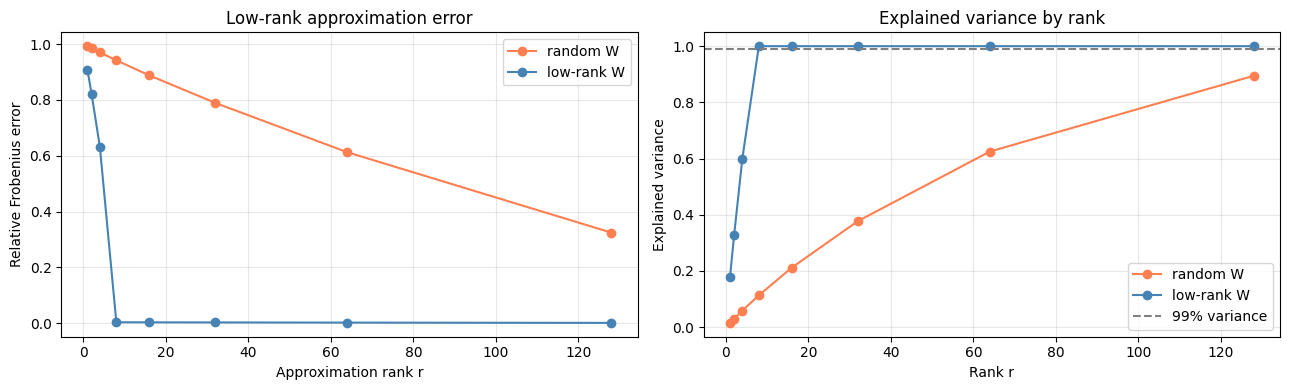

r=  1  random: 0.015  low-rank: 0.177
r=  2  random: 0.030  low-rank: 0.327
r=  4  random: 0.059  low-rank: 0.600
r=  8  random: 0.113  low-rank: 1.000
r= 16  random: 0.212  low-rank: 1.000
r= 32  random: 0.377  low-rank: 1.000
r= 64  random: 0.625  low-rank: 1.000
r=128  random: 0.895  low-rank: 1.000


In [138]:
def low_rank_approx(W: torch.Tensor, rank: int) -> torch.Tensor:
    """
    Best rank-r approximation via truncated SVD (Eckart-Young theorem).
    W = U @ diag(S) @ Vh  →  W_r = U[:,:r] @ diag(S[:r]) @ Vh[:r,:]
    """
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    # Truncate to top-r components
    U_r  = U[:, :rank]           # [d, r]
    S_r  = S[:rank]              # [r]
    Vh_r = Vh[:rank, :]          # [r, k]
    return U_r @ torch.diag(S_r) @ Vh_r

def reconstruction_error(W: torch.Tensor, W_approx: torch.Tensor) -> float:
    """Normalized Frobenius error."""
    return (W - W_approx).norm("fro").item() / W.norm("fro").item()

def explained_variance(W: torch.Tensor, rank: int) -> float:
    """
    Fraction of total spectral energy captured by top-r singular values.
    S^2 = squared singular values = eigenvalues of W^T W.
    """
    S = torch.linalg.svdvals(W)
    return (S[:rank] ** 2).sum().item() / (S ** 2).sum().item()

# Experiment
d, k = 256, 256
ranks = [1, 2, 4, 8, 16, 32, 64, 128]

W_random  = torch.randn(d, k)
r_true    = 8
W_lowrank = torch.randn(d, r_true) @ torch.randn(r_true, k) + 0.01 * torch.randn(d, k)

errors_random  = [reconstruction_error(W_random,  low_rank_approx(W_random,  r)) for r in ranks]
errors_lowrank = [reconstruction_error(W_lowrank, low_rank_approx(W_lowrank, r)) for r in ranks]
varexp_random  = [explained_variance(W_random,  r) for r in ranks]
varexp_lowrank = [explained_variance(W_lowrank, r) for r in ranks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ranks, errors_random,  "o-", label="random W",   color="coral")
ax1.plot(ranks, errors_lowrank, "o-", label="low-rank W", color="steelblue")
ax1.set_xlabel("Approximation rank r"); ax1.set_ylabel("Relative Frobenius error")
ax1.set_title("Low-rank approximation error"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ranks, varexp_random,  "o-", label="random W",   color="coral")
ax2.plot(ranks, varexp_lowrank, "o-", label="low-rank W", color="steelblue")
ax2.axhline(0.99, linestyle="--", color="gray", label="99% variance")
ax2.set_xlabel("Rank r"); ax2.set_ylabel("Explained variance")
ax2.set_title("Explained variance by rank"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

for r, ev_r, ev_l in zip(ranks, varexp_random, varexp_lowrank):
    print(f"r={r:>3}  random: {ev_r:.3f}  low-rank: {ev_l:.3f}")

### 1b — Singular value spectrum of pretrained weights

Pretrained weight matrices are **not random** — their singular values decay smoothly, indicating the weights live on an approximately low-dimensional manifold. The plot below contrasts a random matrix (flat spectrum) against real GPT-2 attention Q-projection weights from different layers.

> **Important distinction:** This plot is *motivational context*, not the core LoRA claim. The LoRA paper (Hu et al., 2021) hypothesizes that the **update** $\Delta W = W_{\text{finetuned}} - W_{\text{pretrained}}$ has low intrinsic rank — i.e., fine-tuning doesn't need to span the full parameter space. We verify this directly in section 1b′ below.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

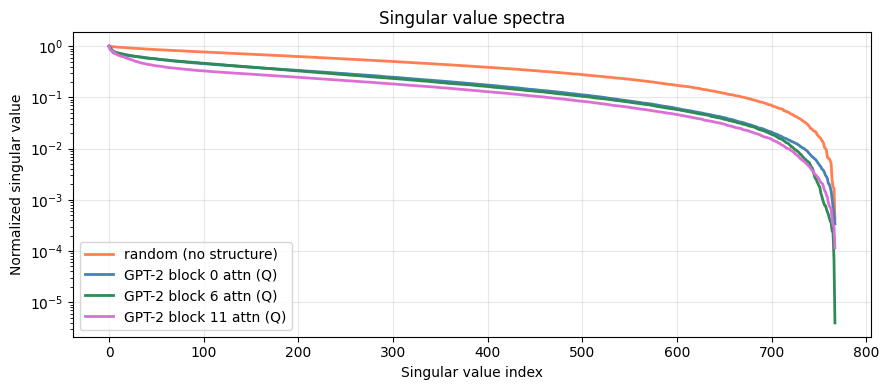

In [139]:
def plot_singular_value_spectrum(matrices: dict, title: str = "Singular value spectra"):
    fig, ax = plt.subplots(figsize=(9, 4))
    colors  = ["coral", "steelblue", "seagreen", "orchid"]
    for (label, W), color in zip(matrices.items(), colors):
        S = torch.linalg.svdvals(W.float())
        S_norm = S / S[0]                         # normalize by largest SV
        ax.plot(S_norm.numpy(), label=label, color=color, linewidth=2)
    ax.set_xlabel("Singular value index"); ax.set_ylabel("Normalized singular value")
    ax.set_title(title); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

from transformers import GPT2Model

gpt2 = GPT2Model.from_pretrained("gpt2")

# GPT-2's Conv1D stores weights as (input_features, output_features).
# c_attn projects to Q, K, V concatenated — slice [:, :768] for the Q projection.
matrices = {
    "random (no structure)":    torch.randn(768, 768),
    "GPT-2 block 0 attn (Q)":  gpt2.h[0].attn.c_attn.weight.data[:, :768].clone(),
    "GPT-2 block 6 attn (Q)":  gpt2.h[6].attn.c_attn.weight.data[:, :768].clone(),
    "GPT-2 block 11 attn (Q)": gpt2.h[11].attn.c_attn.weight.data[:, :768].clone(),
}
plot_singular_value_spectrum(matrices)

del gpt2

### 1b′ — Low-rank structure of fine-tuning updates (ΔW)

The LoRA paper's **core empirical finding**: the weight *update* $\Delta W = W_{\text{finetuned}} - W_{\text{pretrained}}$ during task-specific fine-tuning has a **rapidly decaying singular value spectrum** — far more concentrated than either the pretrained weights or a random matrix of the same shape. This confirms that the change in weights resides in a low-dimensional subspace, which is exactly what LoRA exploits by parameterizing $\Delta W = BA$ with small rank $r$.

Below, we fine-tune GPT-2 for a few steps on a toy next-token prediction task and then compare the SVD of $\Delta W$ to a random baseline.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

step  25/100 | loss = 0.0003
step  50/100 | loss = 0.0182
step  75/100 | loss = 0.0307
step 100/100 | loss = 0.0000


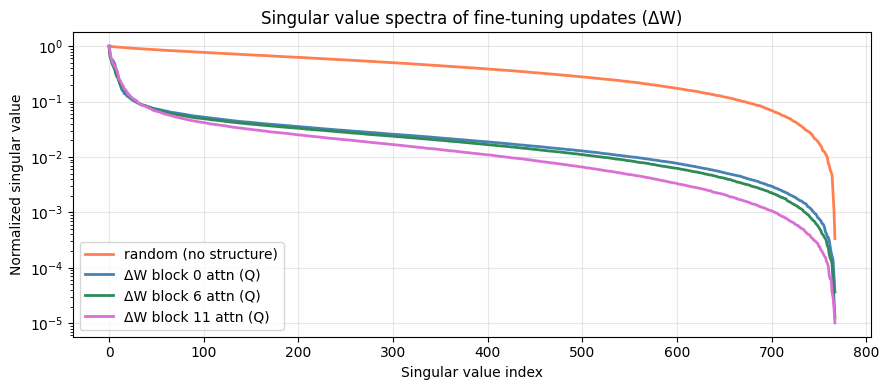

In [140]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model     = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# Snapshot pretrained Q-projection weights before any fine-tuning
layers_to_probe = [0, 6, 11]
W_pretrained = {
    i: model.transformer.h[i].attn.c_attn.weight.data[:, :768].cpu().clone()
    for i in layers_to_probe
}

# ── Quick fine-tuning on a toy task ──────────────────────────────────────
text   = "The quick brown fox jumps over the lazy dog. " * 50
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
inputs = {k: v.to(device) for k, v in inputs.items()}

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
model.train()

n_steps = 100
for step in range(n_steps):
    outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if (step + 1) % 25 == 0:
        print(f"step {step+1:>3}/{n_steps} | loss = {loss.item():.4f}")

# ── Compute ΔW = W_finetuned − W_pretrained ──────────────────────────────
delta_W = {
    f"ΔW block {i} attn (Q)": (
        model.transformer.h[i].attn.c_attn.weight.data[:, :768].cpu() - W_pretrained[i]
    ).clone()
    for i in layers_to_probe
}

matrices = {"random (no structure)": torch.randn(768, 768)}
matrices.update(delta_W)

plot_singular_value_spectrum(
    matrices,
    title="Singular value spectra of fine-tuning updates (ΔW)",
)

del model, tokenizer

### 1c — Rank of BA

In [141]:
def verify_lora_rank(d: int, k: int, r: int):
    B = torch.randn(d, r)
    A = torch.randn(r, k)
    delta_W = B @ A
    rank_dW = torch.linalg.matrix_rank(delta_W).item()
    full_params = d * k
    lora_params = r * (d + k)
    print(f"r={r:>2}  |  delta_W shape: [{d}×{k}]  |  rank(BA)={rank_dW}  |  "
          f"LoRA params: {lora_params:,}  vs full: {full_params:,}  ({lora_params/full_params:.2%})")

for r in [1, 4, 8, 16]:
    verify_lora_rank(d=512, k=512, r=r)

r= 1  |  delta_W shape: [512×512]  |  rank(BA)=1  |  LoRA params: 1,024  vs full: 262,144  (0.39%)
r= 4  |  delta_W shape: [512×512]  |  rank(BA)=4  |  LoRA params: 4,096  vs full: 262,144  (1.56%)
r= 8  |  delta_W shape: [512×512]  |  rank(BA)=8  |  LoRA params: 8,192  vs full: 262,144  (3.12%)
r=16  |  delta_W shape: [512×512]  |  rank(BA)=16  |  LoRA params: 16,384  vs full: 262,144  (6.25%)


---
## Stage 2 — LoRA Layer Implementation

In [142]:
class LoRALinear(nn.Module):
    """
    Linear layer with LoRA bypass.
    h = Wx + (alpha/r) * B A x
    """
    def __init__(
        self,
        in_features:  int,
        out_features: int,
        rank:         int   = 4,
        alpha:        float = None,
        bias:         bool  = True,
    ):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank         = rank
        self.alpha        = alpha if alpha is not None else float(rank)
        self.scaling      = self.alpha / self.rank
        self.merged       = False

        # Frozen pretrained weight — requires_grad=False
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features), requires_grad=False
        )
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter("bias", None)

        # Trainable LoRA matrices
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.empty(out_features, rank))

        self.reset_lora_parameters()

    def reset_lora_parameters(self):
        """
        A ~ kaiming_uniform, B = 0.
        Guarantees delta_W = BA = 0 at init → model starts at pretrained checkpoint.
        """
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base = F.linear(x, self.weight, self.bias)
        if self.merged:
            return base
        # LoRA path: x → A → B, scaled by alpha/r
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B)
        return base + self.scaling * lora

    def merge_weights(self):
        """W ← W + scaling × B @ A  (in-place, zero inference overhead)."""
        if not self.merged:
            self.weight.data += self.scaling * (self.lora_B @ self.lora_A)
            self.merged = True

    def unmerge_weights(self):
        """Undo merge — useful to resume training."""
        if self.merged:
            self.weight.data -= self.scaling * (self.lora_B @ self.lora_A)
            self.merged = False

    def trainable_parameters(self) -> int:
        return self.lora_A.numel() + self.lora_B.numel()

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"r={self.rank}, alpha={self.alpha}, merged={self.merged}")

In [143]:
# Correctness checks
layer = LoRALinear(in_features=64, out_features=32, rank=4, alpha=4)
x     = torch.randn(8, 64)

delta_W = layer.scaling * layer.lora_B @ layer.lora_A
assert delta_W.abs().max().item() == 0.0
print("✓ delta_W = 0 at initialization")

base_out = F.linear(x, layer.weight, layer.bias)
lora_out = layer(x)
assert torch.allclose(base_out, lora_out, atol=1e-6)
print("✓ LoRA output matches base at initialization")

with torch.no_grad():
    layer.lora_B.data = torch.randn_like(layer.lora_B)
assert not torch.allclose(base_out, layer(x))
print("✓ LoRA output changes after B is updated")

out_before = layer(x).clone()
layer.merge_weights()
assert torch.allclose(out_before, layer(x), atol=1e-5)
print("✓ merge_weights() preserves output")

layer.unmerge_weights()
assert torch.allclose(out_before, layer(x), atol=1e-5)
print("✓ unmerge_weights() restores original behavior")

total  = layer.weight.numel() + layer.bias.numel()
lora_p = layer.trainable_parameters()
print(f"\nFull: {total:,}  LoRA trainable: {lora_p:,}  ({lora_p/total:.2%})")

trainable = [p for p in layer.parameters() if p.requires_grad]
assert not any(p is layer.weight for p in trainable)
print("✓ W is frozen")

✓ delta_W = 0 at initialization
✓ LoRA output matches base at initialization
✓ LoRA output changes after B is updated
✓ merge_weights() preserves output
✓ unmerge_weights() restores original behavior

Full: 2,080  LoRA trainable: 384  (18.46%)
✓ W is frozen


### 2b — Parameter count table

In [144]:
def lora_param_efficiency(
    d_model:        int  = 4096,
    ranks:          list = [1, 2, 4, 8, 16, 32, 64],
    n_layers:       int  = 32,
    target_modules: int  = 4,
):
    full_per_layer = d_model * d_model
    full_total     = n_layers * target_modules * full_per_layer

    print(f"Model: d={d_model}, {n_layers} layers, {target_modules} target modules/layer")
    print(f"Full fine-tune: {full_total/1e6:.0f}M params\n")
    print(f"{'r':>4}  {'LoRA params':>14}  {'Ratio':>8}  {'Params/layer':>14}")
    print("-" * 46)
    for r in ranks:
        lora_per_layer = r * (d_model + d_model)     # A + B
        lora_total     = n_layers * target_modules * lora_per_layer
        ratio          = lora_total / full_total
        print(f"{r:>4}  {lora_total/1e6:>13.2f}M  {ratio:>8.3%}  {lora_per_layer/1e3:>12.1f}K")

lora_param_efficiency()

Model: d=4096, 32 layers, 4 target modules/layer
Full fine-tune: 2147M params

   r     LoRA params     Ratio    Params/layer
----------------------------------------------
   1           1.05M    0.049%           8.2K
   2           2.10M    0.098%          16.4K
   4           4.19M    0.195%          32.8K
   8           8.39M    0.391%          65.5K
  16          16.78M    0.781%         131.1K
  32          33.55M    1.562%         262.1K
  64          67.11M    3.125%         524.3K


---
## Stage 3 — Inject LoRA into GPT-2

We load the pretrained GPT-2 (small, 124 M params) from HuggingFace and fine-tune it
on **Wikitext-2** with LoRA.  HuggingFace GPT-2 uses `Conv1D` layers internally;
we convert them to `nn.Linear` so our `LoRALinear` class drops in directly.

In [145]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers.pytorch_utils import Conv1D as HFConv1D
from datasets import load_dataset

# ── 1. Load GPT-2 (small, 124 M params) ──────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def _convert_conv1d_to_linear(model):
    """Replace HuggingFace Conv1D with nn.Linear (functionally identical)."""
    for name, module in list(model.named_modules()):
        if isinstance(module, HFConv1D):
            in_f, out_f = module.weight.shape       # Conv1D: [in, out]
            linear = nn.Linear(in_f, out_f, bias=True, device=module.weight.device)
            linear.weight.data.copy_(module.weight.data.T)
            linear.bias.data.copy_(module.bias.data)
            parts = name.split(".")
            parent = model
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], linear)
    return model

base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
base_model = _convert_conv1d_to_linear(base_model)
print(f"GPT-2 parameters: {sum(p.numel() for p in base_model.parameters()):,}")

# ── 2. Prepare Wikitext-2 training data ───────────────────────────────
SEQ_LEN    = 128
BATCH_SIZE = 8

raw_data = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
all_ids  = []
for row in raw_data:
    text = row["text"].strip()
    if text:
        all_ids.extend(tokenizer.encode(text))

all_ids = torch.tensor(all_ids, dtype=torch.long)
n_seqs  = len(all_ids) // (SEQ_LEN + 1)
all_ids = all_ids[: n_seqs * (SEQ_LEN + 1)].view(n_seqs, SEQ_LEN + 1)
all_ids = all_ids[torch.randperm(len(all_ids))]
print(f"Training sequences: {len(all_ids)}  (seq_len={SEQ_LEN})")

class DataIterator:
    """Cycles through fixed-length token windows, yielding (input, target) pairs."""
    def __init__(self, tokens, device):
        self.tokens = tokens
        self.device = device
        self.idx    = 0

    def get_batch(self, batch_size):
        if self.idx + batch_size > len(self.tokens):
            self.tokens = self.tokens[torch.randperm(len(self.tokens))]
            self.idx = 0
        batch = self.tokens[self.idx : self.idx + batch_size].to(self.device)
        self.idx += batch_size
        return batch[:, :-1], batch[:, 1:]

data_iter = DataIterator(all_ids, device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 parameters: 124,439,808
Training sequences: 18194  (seq_len=128)


In [146]:
def inject_lora(
    model:          nn.Module,
    rank:           int   = 4,
    alpha:          float = None,
    target_modules: list  = ["c_attn"],
) -> nn.Module:
    """
    Replace target nn.Linear modules with LoRALinear in-place.
    """
    for p in model.parameters():
        p.requires_grad = False

    for full_name, module in list(model.named_modules()):
        leaf_name = full_name.split(".")[-1]
        if not isinstance(module, nn.Linear) or leaf_name not in target_modules:
            continue

        lora_layer = LoRALinear(
            in_features  = module.in_features,
            out_features = module.out_features,
            rank         = rank,
            alpha        = alpha,
            bias         = module.bias is not None,
        )
        with torch.no_grad():
            lora_layer.weight.copy_(module.weight)
            if module.bias is not None:
                lora_layer.bias.data.copy_(module.bias.data)

        lora_layer = lora_layer.to(module.weight.device)

        parts      = full_name.split(".")
        parent     = model.get_submodule(".".join(parts[:-1])) if len(parts) > 1 else model
        setattr(parent, parts[-1], lora_layer)

    for module in model.modules():
        if isinstance(module, LoRALinear):
            module.lora_A.requires_grad = True
            module.lora_B.requires_grad = True

    return model

lora_model = copy.deepcopy(base_model)
lora_model = inject_lora(lora_model, rank=4, target_modules=["c_attn"])

total     = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Trainable ratio:  {trainable/total:.2%}\n")
for name, p in lora_model.named_parameters():
    if p.requires_grad:
        print(f"  trainable: {name}  {tuple(p.shape)}")

Total params:     124,587,264
Trainable params: 175,104
Trainable ratio:  0.14%

  trainable: transformer.h.0.attn.c_attn.bias  (2304,)
  trainable: transformer.h.0.attn.c_attn.lora_A  (4, 768)
  trainable: transformer.h.0.attn.c_attn.lora_B  (2304, 4)
  trainable: transformer.h.1.attn.c_attn.bias  (2304,)
  trainable: transformer.h.1.attn.c_attn.lora_A  (4, 768)
  trainable: transformer.h.1.attn.c_attn.lora_B  (2304, 4)
  trainable: transformer.h.2.attn.c_attn.bias  (2304,)
  trainable: transformer.h.2.attn.c_attn.lora_A  (4, 768)
  trainable: transformer.h.2.attn.c_attn.lora_B  (2304, 4)
  trainable: transformer.h.3.attn.c_attn.bias  (2304,)
  trainable: transformer.h.3.attn.c_attn.lora_A  (4, 768)
  trainable: transformer.h.3.attn.c_attn.lora_B  (2304, 4)
  trainable: transformer.h.4.attn.c_attn.bias  (2304,)
  trainable: transformer.h.4.attn.c_attn.lora_A  (4, 768)
  trainable: transformer.h.4.attn.c_attn.lora_B  (2304, 4)
  trainable: transformer.h.5.attn.c_attn.bias  (2304,)
  tr

### 3b — Training loop

In [147]:
def train_loop(
    model,
    data_iter,
    n_steps:    int   = 200,
    batch_size: int   = 8,
    lr:         float = 3e-4,
    label:      str   = "model",
) -> dict:
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    model.train()

    stats = defaultdict(list)
    for step in range(n_steps):
        x, y = data_iter.get_batch(batch_size)

        outputs = model(x)
        logits  = outputs.logits if hasattr(outputs, "logits") else outputs
        loss    = loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1e9).item()
        optimizer.step()

        stats["losses"].append(loss.item())
        stats["grad_norms"].append(grad_norm)

        dw_norms = []
        for m in model.modules():
            if isinstance(m, LoRALinear):
                dw = (m.scaling * m.lora_B @ m.lora_A).norm().item()
                dw_norms.append(dw)
        if dw_norms:
            stats["delta_W_norms"].append(np.mean(dw_norms))

        if (step + 1) % 50 == 0:
            print(f"[{label}] step {step+1:>4}  loss={loss.item():.4f}  grad_norm={grad_norm:.3f}")

    return dict(stats)

In [148]:
full_model = copy.deepcopy(base_model)
for p in full_model.parameters():
    p.requires_grad = True

print("Training full fine-tune (all GPT-2 params)...")
full_stats = train_loop(full_model, data_iter, n_steps=200, batch_size=4, lr=2e-5, label="full")

print("\nTraining LoRA (r=4, c_attn only)...")
lora_model = copy.deepcopy(base_model)
lora_model = inject_lora(lora_model, rank=4, target_modules=["c_attn"])
lora_stats = train_loop(lora_model, data_iter, n_steps=200, batch_size=8, lr=3e-4, label="lora")

Training full fine-tune (all GPT-2 params)...
[full] step   50  loss=3.9124  grad_norm=11.141
[full] step  100  loss=3.6557  grad_norm=10.234
[full] step  150  loss=3.8044  grad_norm=9.710
[full] step  200  loss=3.8542  grad_norm=10.224

Training LoRA (r=4, c_attn only)...
[lora] step   50  loss=4.3002  grad_norm=0.436
[lora] step  100  loss=3.8486  grad_norm=0.418
[lora] step  150  loss=4.2196  grad_norm=0.479
[lora] step  200  loss=3.9048  grad_norm=0.415


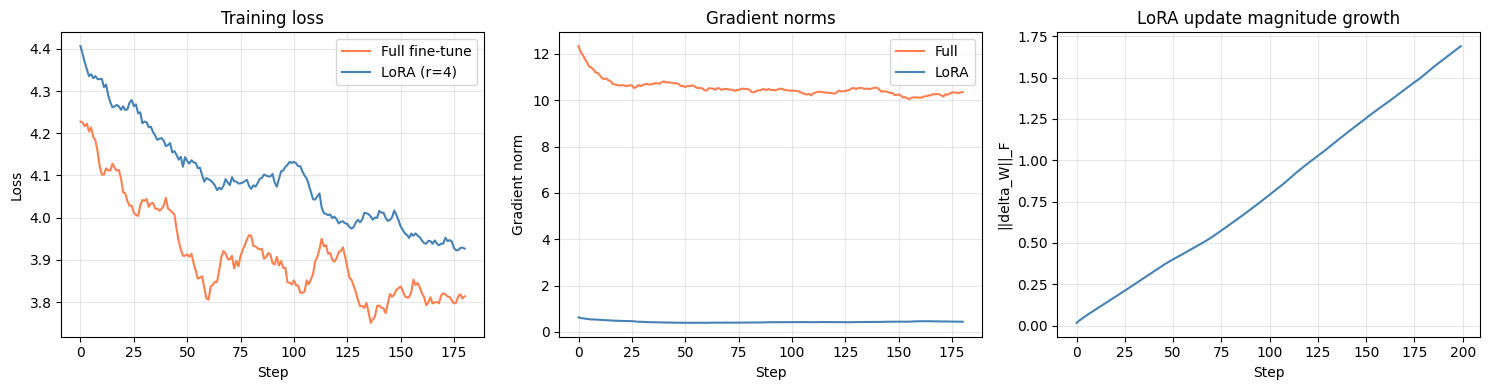

In [149]:
def smooth(vals, w=20):
    return np.convolve(vals, np.ones(w)/w, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Loss curves
axes[0].plot(smooth(full_stats["losses"]), label="Full fine-tune", color="coral")
axes[0].plot(smooth(lora_stats["losses"]), label="LoRA (r=4)",    color="steelblue")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: Gradient norms
axes[1].plot(smooth(full_stats["grad_norms"]), label="Full",  color="coral")
axes[1].plot(smooth(lora_stats["grad_norms"]), label="LoRA",  color="steelblue")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Gradient norm")
axes[1].set_title("Gradient norms"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: ||delta_W|| growth (LoRA only)
if lora_stats.get("delta_W_norms"):
    axes[2].plot(lora_stats["delta_W_norms"], color="steelblue")
    axes[2].set_xlabel("Step"); axes[2].set_ylabel("||delta_W||_F")
    axes[2].set_title("LoRA update magnitude growth")
    axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 3c — Catastrophic forgetting

LoRA's key practical advantage: because the pretrained weights **W** are frozen and the
update is constrained to a low-rank subspace, the model retains its original capabilities
far better than full fine-tuning.  We test this by measuring **validation perplexity**
(on held-out Wikitext-2 data) and comparing **text generation quality** across three
checkpoints: pretrained, full fine-tune, and LoRA.

Validation sequences: 1880


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Model                       Val PPL
------------------------------------
GPT-2 (pretrained)            59.78
Full fine-tune                38.81
LoRA (r=4)                    43.37

Generation samples  (greedy, 50 new tokens)

Prompt: 'The theory of relativity states that'
------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


    Pretrained: The theory of relativity states that the speed of light is proportional to the distance between two points. The speed of light is proportional to the distance between two points.

The theory of relativity states that the speed of light is proportional to the distance between two points. The speed of


...

          LoRA: def fibonacci(n):

The first step in the process of constructing a fibonacci is to find the number n . The first step is to find the number n in the Fibonacci sequence . The second step is to find the number n in the Fibon

Prompt: 'In a shocking turn of events, the president'
------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


    Pretrained: In a shocking turn of events, the president's son-in-law, Jared Kushner, was also named as a senior adviser to the president's son-in-law, Jared Kushner, who is now the president's son-in-law and senior adviser to the president's son-


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


       Full FT: In a shocking turn of events, the president of the United States was assassinated on January 20, 1872 . The assassination was the first time that the United States had been assassinated in the United States since the Civil War . The assassination was the first time that the United States had been assassinated in the
          LoRA: In a shocking turn of events, the president of the United States, Barack Obama, was forced to resign from office after the resignation of his chief of staff, John Kelly , after a series of scandals involving his administration.

The resignation of Kelly was announced by the White House on Friday,


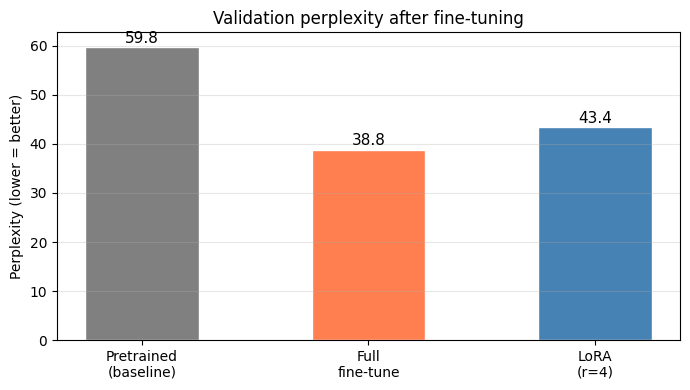

In [150]:
# ── 1. Prepare held-out validation data ───────────────────────────────
val_data = load_dataset("wikitext", "wikitext-2-raw-v1", split="validation")
val_ids  = []
for row in val_data:
    text = row["text"].strip()
    if text:
        val_ids.extend(tokenizer.encode(text))

val_ids = torch.tensor(val_ids, dtype=torch.long)
n_val   = len(val_ids) // (SEQ_LEN + 1)
val_ids = val_ids[: n_val * (SEQ_LEN + 1)].view(n_val, SEQ_LEN + 1)
print(f"Validation sequences: {len(val_ids)}")

# ── 2. Perplexity evaluation ─────────────────────────────────────────
@torch.no_grad()
def compute_perplexity(model, tokens, batch_size=16):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, n_tokens = 0.0, 0
    for i in range(0, len(tokens), batch_size):
        batch = tokens[i : i + batch_size].to(device)
        x, y  = batch[:, :-1], batch[:, 1:]
        outputs = model(x)
        logits  = outputs.logits if hasattr(outputs, "logits") else outputs
        loss    = loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        total_loss += loss.item() * y.numel()
        n_tokens   += y.numel()
    return math.exp(total_loss / n_tokens)

ppl = {
    "GPT-2 (pretrained)": compute_perplexity(base_model, val_ids),
    "Full fine-tune":     compute_perplexity(full_model, val_ids),
    "LoRA (r=4)":         compute_perplexity(lora_model, val_ids),
}

print(f"\n{'Model':<24} {'Val PPL':>10}")
print("-" * 36)
for name, val in ppl.items():
    print(f"{name:<24} {val:>10.2f}")

# ── 3. Qualitative generation comparison ─────────────────────────────
prompts = [
    "The theory of relativity states that",
    "def fibonacci(n):",
    "In a shocking turn of events, the president",
]

print("\n" + "=" * 70)
print("Generation samples  (greedy, 50 new tokens)")
print("=" * 70)
for prompt in prompts:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    print(f"\nPrompt: {prompt!r}")
    print("-" * 60)
    for label, m in [("Pretrained", base_model), ("Full FT", full_model), ("LoRA", lora_model)]:
        m.eval()
        with torch.no_grad():
            out = m.generate(input_ids, max_new_tokens=50, do_sample=False)
        text = tokenizer.decode(out[0], skip_special_tokens=True)
        print(f"  {label:>12}: {text}")

# ── 4. Bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
names  = ["Pretrained\n(baseline)", "Full\nfine-tune", "LoRA\n(r=4)"]
vals   = list(ppl.values())
colors = ["gray", "coral", "steelblue"]
bars   = ax.bar(names, vals, color=colors, width=0.5, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{v:.1f}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Perplexity (lower = better)")
ax.set_title("Validation perplexity after fine-tuning")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

---
## Stage 4 — Training Dynamics

### 4a — B=0 initialization matters

[B=0 (correct)] step   50  loss=4.2308  grad_norm=0.898
[B=0 (correct)] step  100  loss=4.0940  grad_norm=0.427
[B=0 (correct)] step  150  loss=4.1849  grad_norm=0.428
[B=0 (correct)] step  200  loss=3.7569  grad_norm=0.457
[B=random (bad)] step   50  loss=4.3630  grad_norm=0.947
[B=random (bad)] step  100  loss=4.0627  grad_norm=0.813
[B=random (bad)] step  150  loss=4.2627  grad_norm=0.829
[B=random (bad)] step  200  loss=4.2694  grad_norm=0.701


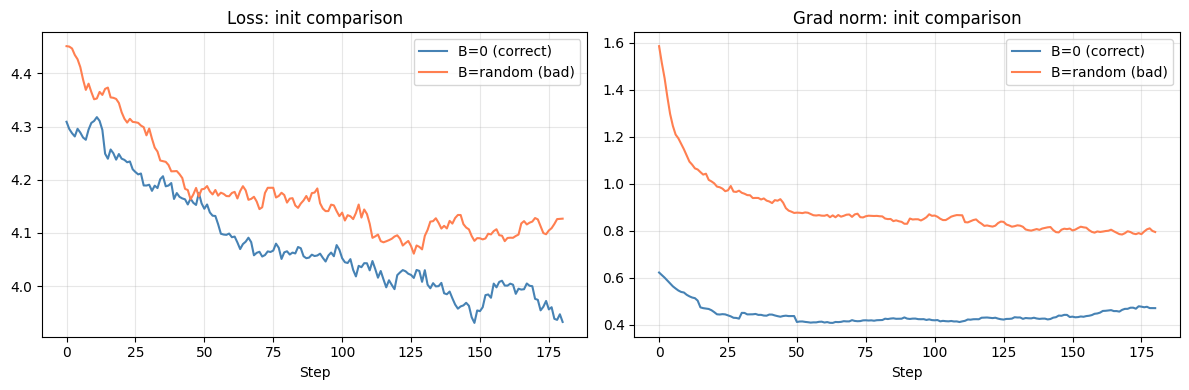

In [151]:
class LoRALinearBadInit(LoRALinear):
    """Same as LoRALinear but B is randomly initialized instead of zero."""
    def reset_lora_parameters(self):
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))

def run_init_experiment() -> dict:
    results = {}
    for name, lora_cls in [("B=0 (correct)", LoRALinear), ("B=random (bad)", LoRALinearBadInit)]:
        m = copy.deepcopy(base_model)
        for p in m.parameters():
            p.requires_grad = False

        for full_name, module in list(m.named_modules()):
            leaf = full_name.split(".")[-1]
            if isinstance(module, nn.Linear) and leaf in ["c_attn"]:
                ll = lora_cls(
                    module.in_features, module.out_features,
                    rank=4, bias=module.bias is not None,
                )
                with torch.no_grad():
                    ll.weight.copy_(module.weight)
                    if module.bias is not None:
                        ll.bias.data.copy_(module.bias.data)
                ll = ll.to(module.weight.device)
                parts  = full_name.split(".")
                parent = m.get_submodule(".".join(parts[:-1])) if len(parts) > 1 else m
                setattr(parent, parts[-1], ll)

        for mod in m.modules():
            if isinstance(mod, LoRALinear):
                mod.lora_A.requires_grad = True
                mod.lora_B.requires_grad = True

        stats = train_loop(m, data_iter, n_steps=200, lr=3e-4, label=name)
        results[name] = stats

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, stats in results.items():
        color = "steelblue" if "correct" in name else "coral"
        axes[0].plot(smooth(stats["losses"]),     label=name, color=color)
        axes[1].plot(smooth(stats["grad_norms"]), label=name, color=color)
    axes[0].set_title("Loss: init comparison");       axes[0].set_xlabel("Step"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_title("Grad norm: init comparison");  axes[1].set_xlabel("Step"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return results

init_results = run_init_experiment()

### 4b — Rank sensitivity

[r=1] step   50  loss=4.3106  grad_norm=0.417
[r=1] step  100  loss=4.3815  grad_norm=0.429
[r=1] step  150  loss=3.9282  grad_norm=0.393
[r=1] step  200  loss=3.8403  grad_norm=0.390
r= 1  loss=3.8403  eff_rank=1.0
[r=2] step   50  loss=4.2793  grad_norm=0.405
[r=2] step  100  loss=4.0544  grad_norm=0.393
[r=2] step  150  loss=3.9628  grad_norm=0.409
[r=2] step  200  loss=3.9822  grad_norm=0.399
r= 2  loss=3.9822  eff_rank=2.0
[r=4] step   50  loss=4.0377  grad_norm=0.424
[r=4] step  100  loss=4.1334  grad_norm=0.408
[r=4] step  150  loss=3.9999  grad_norm=0.466
[r=4] step  200  loss=4.0262  grad_norm=0.427
r= 4  loss=4.0262  eff_rank=4.0
[r=8] step   50  loss=4.2886  grad_norm=0.393
[r=8] step  100  loss=4.0735  grad_norm=0.508
[r=8] step  150  loss=3.8856  grad_norm=0.439
[r=8] step  200  loss=4.0909  grad_norm=0.515
r= 8  loss=4.0909  eff_rank=8.0
[r=16] step   50  loss=4.0523  grad_norm=0.370
[r=16] step  100  loss=4.0041  grad_norm=0.481
[r=16] step  150  loss=3.9421  grad_norm=0

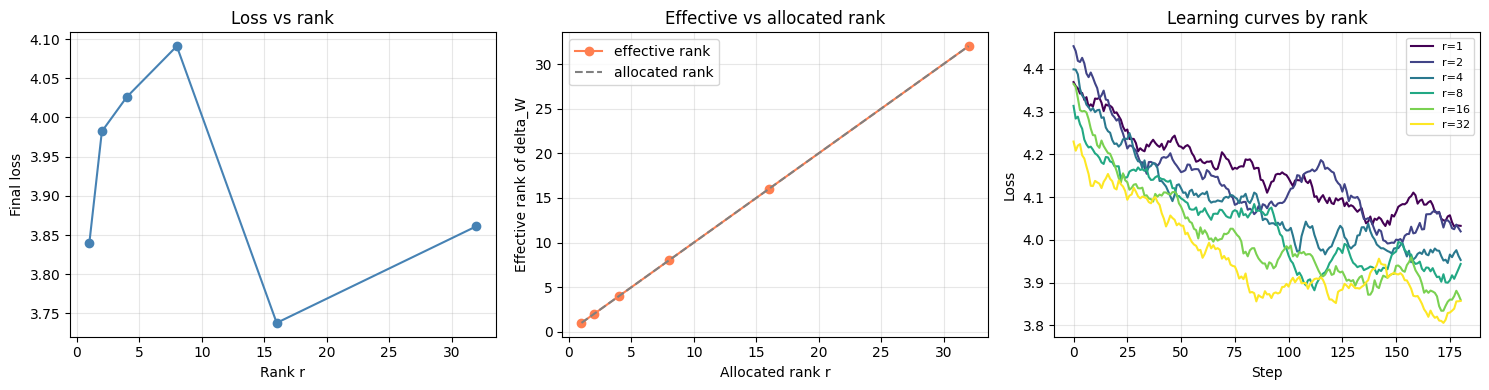

In [152]:
def rank_sensitivity_experiment(
    ranks:   list = [1, 2, 4, 8, 16, 32],
    n_steps: int  = 200,
) -> dict:
    results = {}
    for r in ranks:
        m = copy.deepcopy(base_model)
        m = inject_lora(m, rank=r, target_modules=["c_attn"])
        stats = train_loop(m, data_iter, n_steps=n_steps, lr=3e-4, label=f"r={r}")

        eff_ranks = []
        for mod in m.modules():
            if isinstance(mod, LoRALinear):
                dw       = (mod.scaling * mod.lora_B @ mod.lora_A).detach()
                eff_rank = torch.linalg.matrix_rank(dw, atol=1e-3).item()
                eff_ranks.append(eff_rank)

        results[r] = {
            "final_loss":       stats["losses"][-1],
            "n_trainable":      sum(p.numel() for p in m.parameters() if p.requires_grad),
            "mean_eff_rank":    np.mean(eff_ranks),
            "losses":           stats["losses"],
        }
        print(f"r={r:>2}  loss={results[r]['final_loss']:.4f}  eff_rank={results[r]['mean_eff_rank']:.1f}")
    return results

rank_results = rank_sensitivity_experiment()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rs          = list(rank_results.keys())
final_losses = [rank_results[r]["final_loss"] for r in rs]
eff_ranks    = [rank_results[r]["mean_eff_rank"] for r in rs]

axes[0].plot(rs, final_losses, "o-", color="steelblue")
axes[0].set_xlabel("Rank r"); axes[0].set_ylabel("Final loss")
axes[0].set_title("Loss vs rank"); axes[0].grid(True, alpha=0.3)

axes[1].plot(rs, eff_ranks, "o-", color="coral", label="effective rank")
axes[1].plot(rs, rs, "--", color="gray", label="allocated rank")
axes[1].set_xlabel("Allocated rank r"); axes[1].set_ylabel("Effective rank of delta_W")
axes[1].set_title("Effective vs allocated rank")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

colors_r = plt.cm.viridis(np.linspace(0, 1, len(rs)))
for r, color in zip(rs, colors_r):
    axes[2].plot(smooth(rank_results[r]["losses"]), label=f"r={r}", color=color)
axes[2].set_xlabel("Step"); axes[2].set_ylabel("Loss")
axes[2].set_title("Learning curves by rank"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 4c — Alpha / scaling sensitivity

[α=0.5] step   50  loss=4.3387  grad_norm=0.403
[α=0.5] step  100  loss=4.0730  grad_norm=0.332
[α=0.5] step  150  loss=4.1488  grad_norm=0.752
[α=0.5] step  200  loss=4.0697  grad_norm=0.358
[α=1] step   50  loss=4.5326  grad_norm=0.480
[α=1] step  100  loss=4.0452  grad_norm=0.318
[α=1] step  150  loss=4.1996  grad_norm=0.337
[α=1] step  200  loss=4.1826  grad_norm=0.293
[α=2] step   50  loss=4.0615  grad_norm=0.358
[α=2] step  100  loss=4.0559  grad_norm=0.441
[α=2] step  150  loss=4.2404  grad_norm=0.364
[α=2] step  200  loss=4.1161  grad_norm=0.314
[α=4] step   50  loss=4.2797  grad_norm=0.436
[α=4] step  100  loss=4.1573  grad_norm=0.381
[α=4] step  150  loss=4.2756  grad_norm=0.461
[α=4] step  200  loss=3.9223  grad_norm=0.363
[α=8] step   50  loss=4.2259  grad_norm=0.448
[α=8] step  100  loss=3.9439  grad_norm=0.419
[α=8] step  150  loss=4.1297  grad_norm=0.464
[α=8] step  200  loss=4.1184  grad_norm=0.477
[α=16] step   50  loss=3.9575  grad_norm=0.507
[α=16] step  100  loss=3.

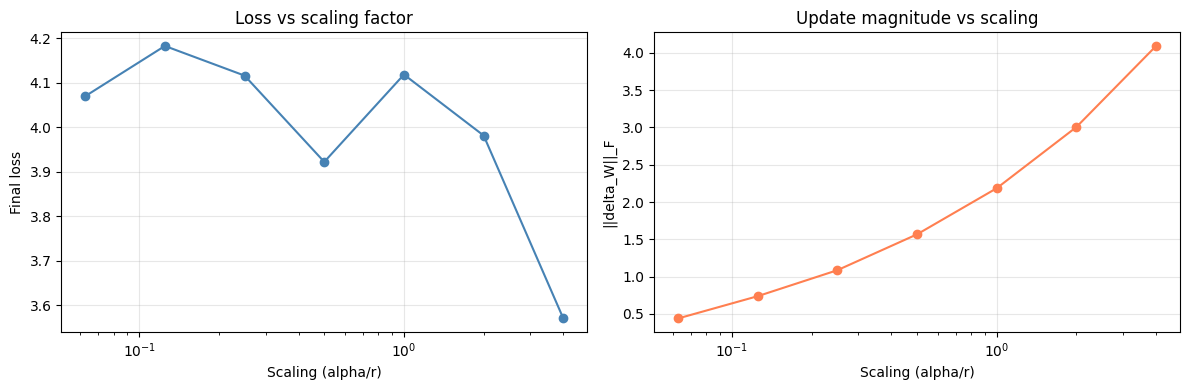

Key insight: alpha acts as a multiplier on effective LR for the LoRA update.
Too small → update too weak. Too large → unstable / overpowers pretrained weights.


In [153]:
def alpha_sensitivity_experiment(
    rank:    int   = 8,
    alphas:  list  = [0.5, 1, 2, 4, 8, 16, 32],
    n_steps: int   = 200,
    lr:      float = 3e-4,
) -> dict:
    results = {}
    for alpha in alphas:
        m = copy.deepcopy(base_model)
        m = inject_lora(m, rank=rank, alpha=alpha, target_modules=["c_attn"])
        stats = train_loop(m, data_iter, n_steps=n_steps, lr=lr, label=f"\u03b1={alpha}")

        dw_norms = []
        for mod in m.modules():
            if isinstance(mod, LoRALinear):
                dw_norms.append((mod.scaling * mod.lora_B @ mod.lora_A).norm().item())

        results[alpha] = {
            "final_loss":    stats["losses"][-1],
            "mean_dW_norm":  np.mean(dw_norms),
            "scaling":       alpha / rank,
            "losses":        stats["losses"],
        }
    return results

alpha_results = alpha_sensitivity_experiment()

scalings     = [v["scaling"]     for v in alpha_results.values()]
final_losses = [v["final_loss"]  for v in alpha_results.values()]
dw_norms     = [v["mean_dW_norm"] for v in alpha_results.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(scalings, final_losses, "o-", color="steelblue")
ax1.set_xlabel("Scaling (alpha/r)"); ax1.set_ylabel("Final loss")
ax1.set_title("Loss vs scaling factor"); ax1.set_xscale("log"); ax1.grid(True, alpha=0.3)

ax2.plot(scalings, dw_norms, "o-", color="coral")
ax2.set_xlabel("Scaling (alpha/r)"); ax2.set_ylabel("||delta_W||_F")
ax2.set_title("Update magnitude vs scaling"); ax2.set_xscale("log"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Key insight: alpha acts as a multiplier on effective LR for the LoRA update.")
print("Too small \u2192 update too weak. Too large \u2192 unstable / overpowers pretrained weights.")

### 4d — Intrinsic rank of learned delta_W

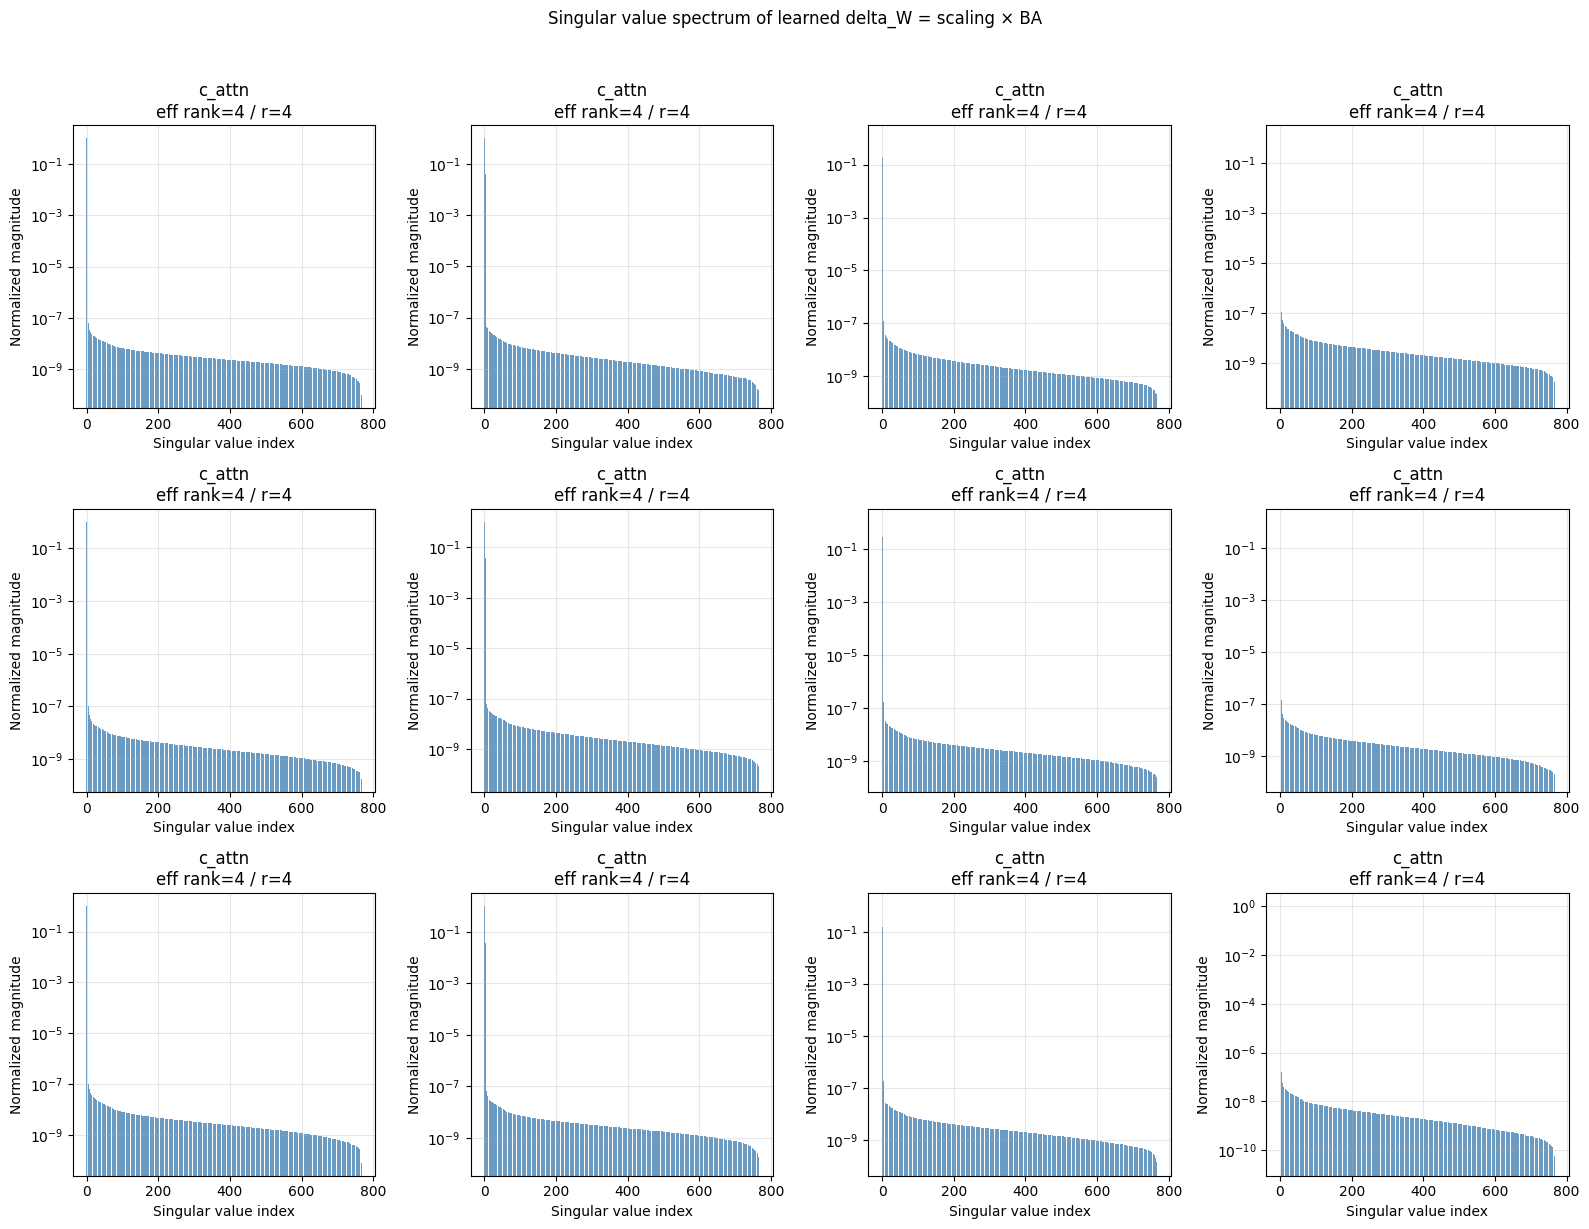

In [154]:
def analyze_learned_delta_W(model: nn.Module) -> None:
    lora_layers = [(n, m) for n, m in model.named_modules() if isinstance(m, LoRALinear)]
    n_layers    = len(lora_layers)
    if n_layers == 0:
        print("No LoRA layers found.")
        return

    n_cols  = min(4, n_layers)
    n_rows  = math.ceil(n_layers / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for ax, (name, m) in zip(axes, lora_layers):
        dw   = (m.scaling * m.lora_B @ m.lora_A).detach()
        S    = torch.linalg.svdvals(dw.float())
        S_n  = (S / S[0]).cpu().numpy()
        eff  = torch.linalg.matrix_rank(dw, atol=1e-3).item()

        ax.bar(range(len(S_n)), S_n, color="steelblue", alpha=0.8)
        ax.set_xlabel("Singular value index")
        ax.set_ylabel("Normalized magnitude")
        ax.set_title(f"{name.split('.')[-1]}\neff rank={eff} / r={m.rank}")
        ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    for ax in axes[n_layers:]:
        ax.set_visible(False)
    plt.suptitle("Singular value spectrum of learned delta_W = scaling × BA", y=1.02)
    plt.tight_layout(); plt.show()

analyze_learned_delta_W(lora_model)

---
## Stage 5 — Weight Merging and Inference

In [155]:
def merge_all_lora_layers(model: nn.Module) -> nn.Module:
    for m in model.modules():
        if isinstance(m, LoRALinear):
            m.merge_weights()
    return model

def convert_lora_to_linear(model: nn.Module) -> nn.Module:
    """Merge + replace LoRALinear → nn.Linear for zero LoRA overhead."""
    merge_all_lora_layers(model)

    for full_name, module in list(model.named_modules()):
        if not isinstance(module, LoRALinear):
            continue
        new_linear = nn.Linear(
            module.in_features, module.out_features,
            bias=(module.bias is not None)
        )
        with torch.no_grad():
            new_linear.weight.copy_(module.weight)
            if module.bias is not None:
                new_linear.bias.copy_(module.bias)
        new_linear = new_linear.to(module.weight.device)
        parts  = full_name.split(".")
        parent = model.get_submodule(".".join(parts[:-1])) if len(parts) > 1 else model
        setattr(parent, parts[-1], new_linear)

    return model

In [156]:
test_text = "The quick brown fox jumps over the lazy dog. In the beginning there was"
test_ids  = tokenizer.encode(test_text, return_tensors="pt").to(device)

lora_model.eval()
out_before = lora_model(test_ids).logits.detach()

merged_model = copy.deepcopy(lora_model)
merged_model = merge_all_lora_layers(merged_model)
assert torch.allclose(out_before, merged_model(test_ids).logits.detach(), atol=1e-4)
print("\u2713 Merged model outputs match")

converted_model = convert_lora_to_linear(copy.deepcopy(lora_model))
assert torch.allclose(out_before, converted_model(test_ids).logits.detach(), atol=1e-4)
print("\u2713 Converted model outputs match")

models_to_bench = {
    "LoRA (unmerged)": lora_model,
    "LoRA (merged)":   merged_model,
    "Plain Linear":    converted_model,
}
n_warmup, n_bench = 10, 100
print(f"\n{'Model':<22}  {'ms/pass':>10}")
print("-" * 36)
for name, m in models_to_bench.items():
    m.eval()
    with torch.no_grad():
        for _ in range(n_warmup): m(test_ids)
        t0 = time.time()
        for _ in range(n_bench):  m(test_ids)
        ms = (time.time() - t0) / n_bench * 1000
    print(f"{name:<22}  {ms:>10.3f}")

✓ Merged model outputs match
✓ Converted model outputs match

Model                      ms/pass
------------------------------------
LoRA (unmerged)             11.369
LoRA (merged)                9.882
Plain Linear                 9.768


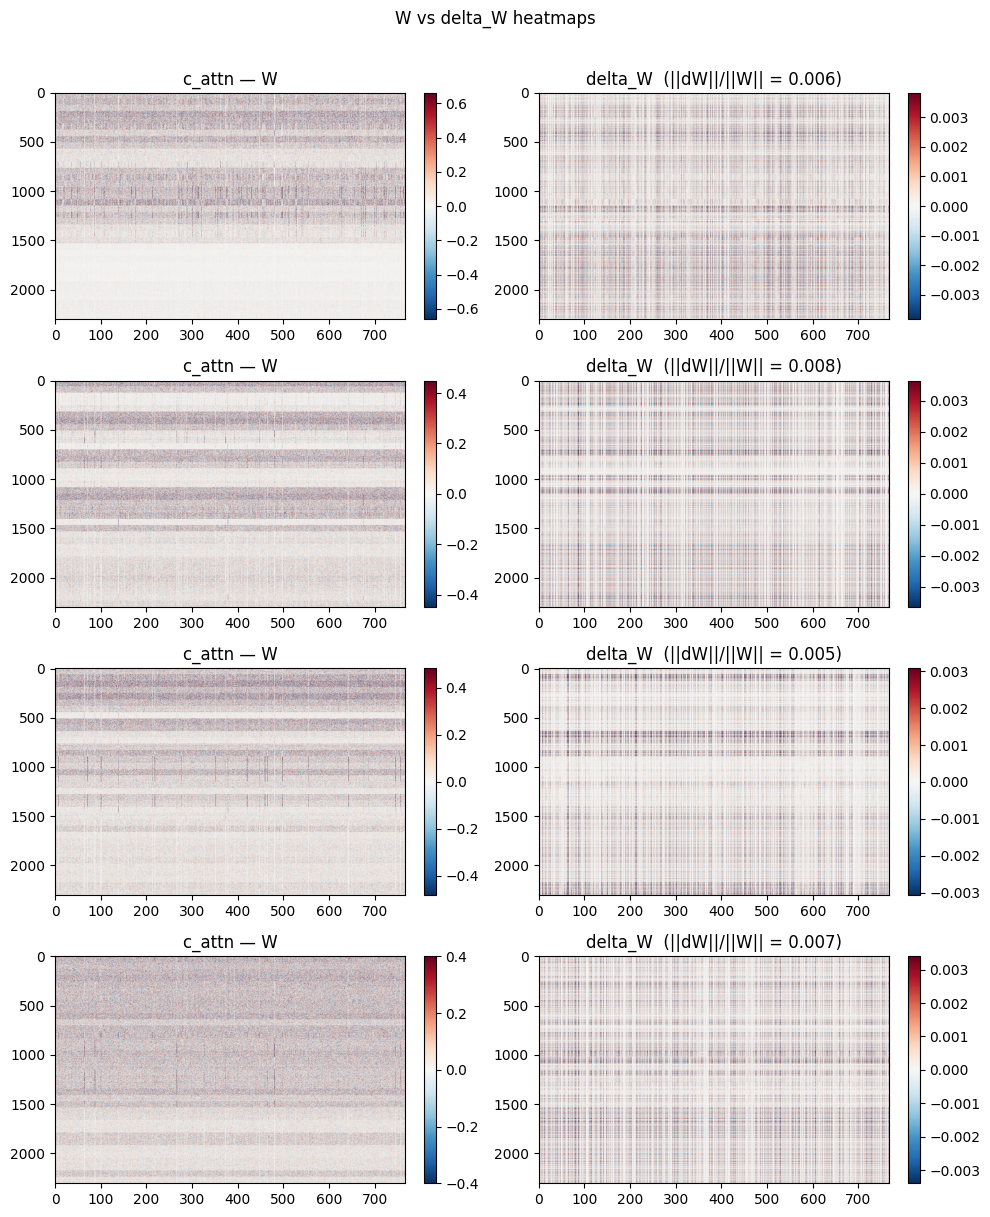

In [157]:
def visualize_lora_updates(model: nn.Module, max_layers: int = 4) -> None:
    lora_layers = [(n, m) for n, m in model.named_modules() if isinstance(m, LoRALinear)]
    lora_layers = lora_layers[:max_layers]
    if not lora_layers:
        return

    fig, axes = plt.subplots(len(lora_layers), 2, figsize=(10, 3 * len(lora_layers)))
    if len(lora_layers) == 1:
        axes = [axes]

    for row, (name, m) in enumerate(lora_layers):
        W  = m.weight.detach().cpu().float()
        dW = (m.scaling * m.lora_B @ m.lora_A).detach().cpu().float()
        ratio = dW.norm().item() / W.norm().item()

        vmax_W  = W.abs().quantile(0.99).item()
        vmax_dW = dW.abs().quantile(0.99).item() if dW.abs().max() > 1e-8 else 0.1

        im0 = axes[row][0].imshow(W.numpy(),  cmap="RdBu_r", vmin=-vmax_W,  vmax=vmax_W,  aspect="auto")
        im1 = axes[row][1].imshow(dW.numpy(), cmap="RdBu_r", vmin=-vmax_dW, vmax=vmax_dW, aspect="auto")
        axes[row][0].set_title(f"{name.split('.')[-1]} — W")
        axes[row][1].set_title(f"delta_W  (||dW||/||W|| = {ratio:.3f})")
        plt.colorbar(im0, ax=axes[row][0], fraction=0.03)
        plt.colorbar(im1, ax=axes[row][1], fraction=0.03)

    plt.suptitle("W vs delta_W heatmaps", y=1.01)
    plt.tight_layout(); plt.show()

visualize_lora_updates(lora_model)

---
## Appendix — Why the Scaling Works

The LoRA paper uses `scaling = alpha / r`. This is more subtle than it looks.

**Without scaling** (`scaling = 1`):
When you increase `r`, more parameters → larger initial gradient signal → effectively larger learning rate for the LoRA path. Changing `r` forces you to retune `lr`.

**With `alpha / r` scaling**:
The effective learning rate for the LoRA update becomes proportional to `lr × alpha / r`.
Setting `alpha = r` makes scaling = 1. Setting `alpha = 2r` doubles the effective LoRA lr.

This decouples `r` from `lr` — you can sweep ranks without retuning the optimizer.

**In practice**: The original paper uses `alpha = r` (scaling=1) or `alpha = 2r`.
For large models, `alpha = 16` with various `r` works well as a default.

---

## Key Numbers to Know (LLaMA-7B)

| | Full fine-tune | LoRA (r=8) | LoRA (r=16) |
|---|---|---|---|
| Trainable params | 7B | ~4M | ~8M |
| % of total | 100% | 0.06% | 0.12% |
| GPU memory | ~112 GB | ~14 GB | ~14 GB |
| Convergence | slow | fast | fast |


---
## Extension Exercises

**1. QLoRA**
Quantize W to int8, keep A and B in fp32. Measure memory vs accuracy.

**2. AdaLoRA**
Periodically SVD delta_W and prune smallest singular values.
Redistribute rank budget from unimportant layers to important ones.

**3. LoRA for feed-forward layers**
Apply to up/down projections. Compare efficiency vs attention-only.

**4. Multi-task merging**
W' = W + alpha1*B1A1 + alpha2*B2A2. Show adapters can be linearly combined.

**5. Rank collapse analysis**
Train r=32 on a simple task. Plot singular value spectrum at checkpoints 0/100/300/500.
Observe how many SVs survive — that's the intrinsic rank of the task.